In [1]:
import scipy
import numpy as np
import pandas as pd

import sklearn.metrics
from clustereval import *

import matplotlib.pyplot as plt
import pyrepseq.plotting as pp
plt.style.use('clustereval.mplstyle')

import warnings
warnings.filterwarnings('ignore', category=UserWarning)

In [2]:
rng = np.random.default_rng(42)  # for reproducibility

# Three shifted centers (means)
means = np.array([[0.0, 0.0],
                  [-3.5, 0.0],
                  [3.5, 0.0]])

nsamples = 40
# Unit covariance (identity), sampled via standard normals + mean shift
samples = rng.normal(size=(3, nsamples, 2)) + means[:, None, :]
labels_true = np.repeat([0, 1, 2], nsamples)
samples_flat = samples.reshape(-1, 2)

In [3]:
def scan_thresholds(pdist, labels_true, max_threshold=None):

    hkcs = []
    hks = []
    Is = []

    homogeneities = []
    parsimonies = []
    completenesss = []

    purities = []
    normalized_purities = []
    inverse_purities = []
    normalized_inverse_purities = []
    retentions = []
    pair_specificities = []
    pair_sensitivities = []

    linkage = scipy.cluster.hierarchy.linkage(pdist, method='single')
    thresholds = linkage[:, 2]

    # append max_threshold to thresholds if provided
    # this extends plotted lines for easier visualization
    if max_threshold is not None:
        thresholds = np.concatenate((thresholds, [max_threshold]))

    for threshold in thresholds:
        labels_pred = scipy.cluster.hierarchy.fcluster(linkage, threshold, criterion='distance')

        entropy_joint, entropy_CK, entropy_KC, entropy_C, entropy_K = conditional_entropies(labels_true, labels_pred)
        hkc = entropy_KC/np.log(2)
        hk = entropy_K/np.log(2)
        i = np.clip(entropy_K - entropy_KC, 0.0, None)/np.log(2)
        hkcs.append(hkc)
        hks.append(hk)
        Is.append(i)
        
        homogeneities.append(homogeneity_score(labels_true, labels_pred))
        parsimonies.append(parsimony_score(labels_true, labels_pred))
        completenesss.append(completeness_score(labels_true, labels_pred))

        purities.append(purity_score(labels_true, labels_pred))
        inverse_purities.append(inverse_purity_score(labels_true, labels_pred))
        normalized_purities.append(normalized_purity_score(labels_true, labels_pred))
        normalized_inverse_purities.append(normalized_inverse_purity_score(labels_true, labels_pred))

        cluster_sizes = pd.Series(labels_pred).value_counts()
        retention = cluster_sizes[cluster_sizes>1].sum() / len(labels_true)
        retentions.append(retention)

        pair_sensitivities.append(pair_sensitivity_score(labels_true, labels_pred))
        pair_specificities.append(pair_specificity_score(labels_true, labels_pred))
        
    df = pd.DataFrame({'HKC': hkcs,
                         'HK': hks,
                         'I': Is,
                         'Threshold': thresholds,
                         'Homogeneity': homogeneities,
                         'Parsimony': parsimonies,
                         'Completeness': completenesss,
                         'Purity': purities,
                         'Normalized_Purity': normalized_purities,
                         'Inverse_Purity': inverse_purities,
                         'Normalized_Inverse_Purity': normalized_inverse_purities,
                         'Retention': retentions,
                         'Pair_Sensitivity': pair_sensitivities,
                         'Pair_Specificity': pair_specificities,
                        })
    df['Pair_FPR'] = 1 - df['Pair_Specificity']
    return df

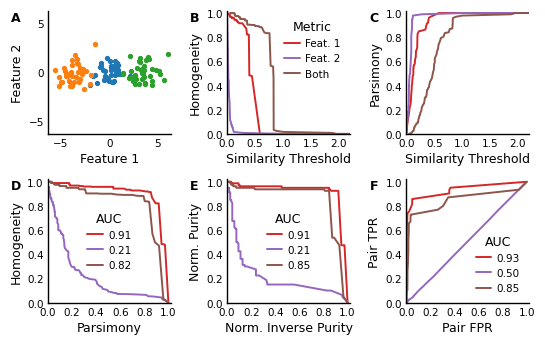

In [4]:
max_threshold = 2.2

fig, axes_arr = plt.subplots(figsize=(5.5, 3.5), ncols=3, nrows=2)
axes = axes_arr.flatten()

lim = np.max(np.abs(samples)) * 1.05

axes[0].plot(samples[0, :, 0], samples[0, :, 1], 'o', ms=3, label='Class 1')
axes[0].plot(samples[1, :, 0], samples[1, :, 1], 'o', ms=3, label='Class 2')
axes[0].plot(samples[2, :, 0], samples[2, :, 1], 'o', ms=3, label='Class 3')

axes[0].set_xlim(-lim, lim)
axes[0].set_ylim(-lim, lim)
axes[0].set_xticks([-5, 0, 5])
axes[0].set_yticks([-5, 0, 5])
axes[0].set_ylabel('Feature 2')
axes[0].set_xlabel('Feature 1')

x_axis, y_axis = 'Parsimony', 'Homogeneity'
x_axis_2, y_axis_2 = 'Normalized_Inverse_Purity', 'Normalized_Purity'
x_axis_3, y_axis_3 = 'Pair_FPR', 'Pair_Sensitivity'

pdist = scipy.spatial.distance.pdist(samples_flat[:, 0][:, None])
results = scan_thresholds(pdist, labels_true, max_threshold=max_threshold)
auc = sklearn.metrics.auc(results[x_axis_3], results[y_axis_3])
axes[5].plot(results[x_axis_3], results[y_axis_3], '-', label=f'{auc:.2f}', color='C3')
auc = sklearn.metrics.auc(results[x_axis_2], results[y_axis_2])
axes[4].plot(results[x_axis_2], results[y_axis_2], '-', label=f'{auc:.2f}', color='C3')
auc = sklearn.metrics.auc(results[x_axis], results[y_axis])
axes[3].plot(results[x_axis], results[y_axis], '-',  label=f'{auc:.2f}', color='C3') 
axes[1].plot(results['Threshold'], results['Homogeneity'], '-',  label=f'Feat. 1', color='C3')
axes[2].plot(results['Threshold'], results['Parsimony'], '-',  label=f'Feat. 1', color='C3')


pdist = scipy.spatial.distance.pdist(samples_flat[:, 1][:, None])
results = scan_thresholds(pdist, labels_true, max_threshold=max_threshold)
auc = sklearn.metrics.auc(results[x_axis_3], results[y_axis_3])
axes[5].plot(results[x_axis_3], results[y_axis_3], '-', label=f'{auc:.2f}', color='C4')
auc = sklearn.metrics.auc(results[x_axis_2], results[y_axis_2])
axes[4].plot(results[x_axis_2], results[y_axis_2], '-', label=f'{auc:.2f}', color='C4')
auc = sklearn.metrics.auc(results[x_axis], results[y_axis])
axes[3].plot(results[x_axis], results[y_axis], '-',  label=f'{auc:.2f}', color='C4') 
axes[1].plot(results['Threshold'], results['Homogeneity'], '-',  label=f'Feat. 2', color='C4')
axes[2].plot(results['Threshold'], results['Parsimony'], '-',  label=f'Feat. 2', color='C4')

pdist = scipy.spatial.distance.pdist(samples_flat)
results = scan_thresholds(pdist, labels_true, max_threshold=max_threshold)
auc_3 = sklearn.metrics.auc(results[x_axis_3], results[y_axis_3])
axes[5].plot(results[x_axis_3], results[y_axis_3], '-', label=f'{auc_3:.2f}', color='C5')
auc_2 = sklearn.metrics.auc(results[x_axis_2], results[y_axis_2])
axes[4].plot(results[x_axis_2], results[y_axis_2], '-', label=f'{auc_2:.2f}', color='C5')
auc = sklearn.metrics.auc(results[x_axis], results[y_axis])
axes[3].plot(results[x_axis], results[y_axis], '-', label=f'{auc:.2f}', color='C5')
axes[1].plot(results['Threshold'], results['Homogeneity'], '-',  label=f'Both', color='C5')
axes[2].plot(results['Threshold'], results['Parsimony'], '-',  label=f'Both', color='C5')

axes[1].legend(title='Metric', loc='upper right', fontsize='small')
axes[1].set_xlabel('Similarity Threshold')
axes[1].set_ylabel(y_axis)

axes[2].set_xlabel('Similarity Threshold')
axes[2].set_ylabel('Parsimony')

axes[3].legend(title='AUC', loc='center', fontsize='small')
axes[3].set_xlabel(x_axis)
axes[3].set_ylabel(y_axis)

axes[4].legend(title='AUC', loc='center', fontsize='small')
axes[4].set_xlabel('Norm. Inverse Purity')
axes[4].set_ylabel('Norm. Purity')


axes[5].legend(title='AUC', loc='lower right', fontsize='small')
axes[5].set_xlabel('Pair FPR')
axes[5].set_ylabel('Pair TPR')

for ax in axes[3:]:
    ax.set_xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_xlim(0.0, 1.02)
    ax.set_ylim(0.0, 1.02)

for ax in axes[1:3]:
    ax.set_xticks([0.0, 0.5, 1.0, 1.5, 2.0])
    ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_xlim(0.0, max_threshold)
    ax.set_ylim(0.0, 1.02)

fig.tight_layout(pad=1.0)
pp.label_axes(axes, xy=(-0.3, 1.0))